# GST operator — forward and inverse, on the 16 test images

The minimal Python version of OrientationJ: one module,
[gst_operator.py](gst_operator.py), with two functions —

- **`forward(image, sigma)`** → (C, E, orientation): Gaussian-derivative
  gradient and Gaussian tensor window, analytic in Fourier; only the three
  OrientationJ features.
- **`inverse(C, E, orientation, sigma)`** → image: the naive blind
  reconstruction (eigenvalues → tensor → Tikhonov deconvolution → half-angle
  square root with 2D phase unwrapping → Tikhonov integration).

This notebook runs the full loop image → (C, E, θ) → image on the 16 images of
`orientationj-test-images/`, at two gradient scales (σ_G = 1 and 5), and
scores PSNR after aligning the two strict invariances of the features (mean
gray level, global contrast flip).

In [1]:
import glob
import os

import numpy as np
import matplotlib.pyplot as plt

from gst_operator import forward, inverse, load_image

SIGMA = 1.0           # structure-tensor window
LAMBDA = 1e-5         # regularisation of both Tikhonov solves
SCALES = (1.0, 5.0)   # gradient widths sigma_G
OUTPUT = 'results'
os.makedirs(OUTPUT, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white', 'font.size': 10, 'axes.titlesize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#cfcec6', 'grid.color': '#e8e8e4', 'grid.linewidth': 0.8,
    'text.color': '#3a3a37', 'axes.labelcolor': '#3a3a37',
    'xtick.color': '#6b6a63', 'ytick.color': '#6b6a63'})

paths = sorted(glob.glob(os.path.join('..', '..', 'orientationj-test-images', 'images', '*.tif')))
IMAGES = {os.path.basename(p)[:-4]: load_image(p) for p in paths}
print(len(IMAGES), 'images —', ', '.join(IMAGES))

16 images — cell_aemisegger, collagen, dendrochronology, fibronectin_arafat_plos2025, fibrous_tissues_fibero2024, fiji_directionality_montage, nanofiber_fiji_diameterj, polymer_slice_quanfima2018, synthetic_chirp_1024, synthetic_filaments_512, synthetic_nematic_512, synthetic_noise_512, synthetic_rings_dither_512, synthetic_spiral_512, synthetic_wave_512, z_artificial_fibers


## The forward model on one image

`forward(image, sigma)` returns the three feature maps (C, E, θ).

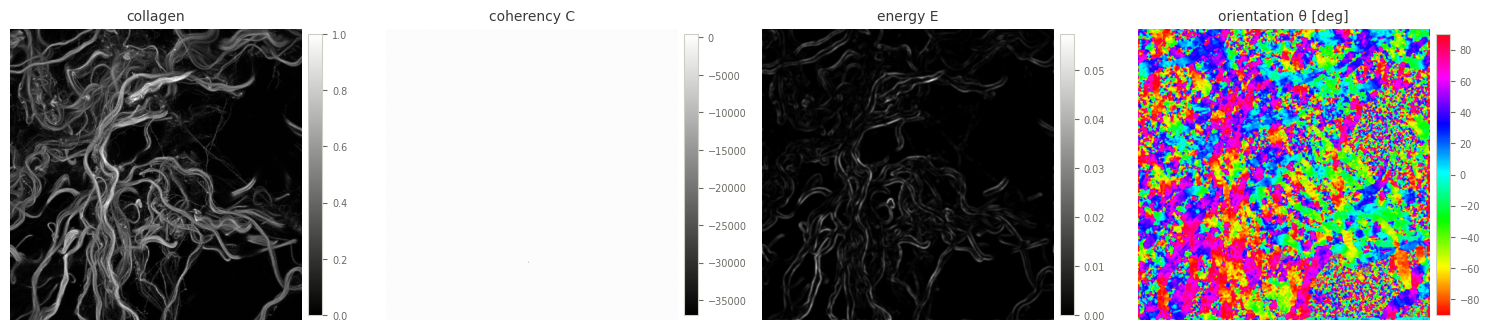

In [2]:
C, E, theta = forward(IMAGES['collagen'], sigma=SIGMA)

fig, axes = plt.subplots(1, 4, figsize=(15, 4.0))
for ax, (array, cmap, title) in zip(axes, [
        (IMAGES['collagen'], 'gray', 'collagen'),
        (C, 'gray', 'coherency C'),
        (E, 'gray', 'energy E'),
        (np.degrees(theta), 'hsv', 'orientation θ [deg]')]):
    m = ax.imshow(array, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(m, ax=ax, fraction=0.045, pad=0.02).ax.tick_params(labelsize=7)
fig.tight_layout()
plt.show()

## Blind reconstruction of the 16 images

For each image and each gradient scale: `forward` → features → `inverse` → PSNR after aligning the two invariances (mean, flip).

In [3]:
def psnr_aligned(rec, image):
    """PSNR after aligning the two strict invariances of the features:
    the mean gray level and the global contrast flip (evaluation only)."""
    candidates = [s * rec - (s * rec).mean() + image.mean() for s in (1.0, -1.0)]
    best = min(candidates, key=lambda c: np.mean((c - image) ** 2))
    return 20 * np.log10(1.0 / np.sqrt(np.mean((best - image) ** 2))), best


psnr = {scale: {} for scale in SCALES}
reconstructions = {}
for name, image in IMAGES.items():
    for scale in SCALES:
        C, E, theta = forward(image, sigma=SIGMA, sigma_gradient=scale)
        rec = inverse(C, E, theta, sigma=SIGMA, lambda_reg=LAMBDA,
                      sigma_gradient=scale)
        psnr[scale][name], aligned = psnr_aligned(rec, image)
        if scale == SCALES[-1]:
            reconstructions[name] = aligned
    print(f'{name:36s}' + ''.join(
        f'  sigma_G={scale:g}: {psnr[scale][name]:6.1f} dB' for scale in SCALES))

cell_aemisegger                       sigma_G=1:    4.7 dB  sigma_G=5:   24.8 dB


collagen                              sigma_G=1:    4.6 dB  sigma_G=5:   15.8 dB


dendrochronology                      sigma_G=1:   -7.2 dB  sigma_G=5:   14.9 dB


fibronectin_arafat_plos2025           sigma_G=1:    0.8 dB  sigma_G=5:   11.8 dB


fibrous_tissues_fibero2024            sigma_G=1:   10.8 dB  sigma_G=5:   23.4 dB


...

synthetic_noise_512                   sigma_G=1:    5.2 dB  sigma_G=5:   21.3 dB


synthetic_rings_dither_512            sigma_G=1:   -0.1 dB  sigma_G=5:    2.4 dB


synthetic_spiral_512                  sigma_G=1:  -15.8 dB  sigma_G=5:   -8.7 dB


synthetic_wave_512                    sigma_G=1:    0.2 dB  sigma_G=5:   11.4 dB


z_artificial_fibers                   sigma_G=1:    3.1 dB  sigma_G=5:   15.0 dB


## Overview — ground truth and blind reconstruction (σ_G = 5)

Left of each pair: ground truth; right: the blind reconstruction. The
recognizable ones are the images whose gradient field is smooth at this scale;
the oscillating ones (chirp, rings, spiral) stay lost at any scale.

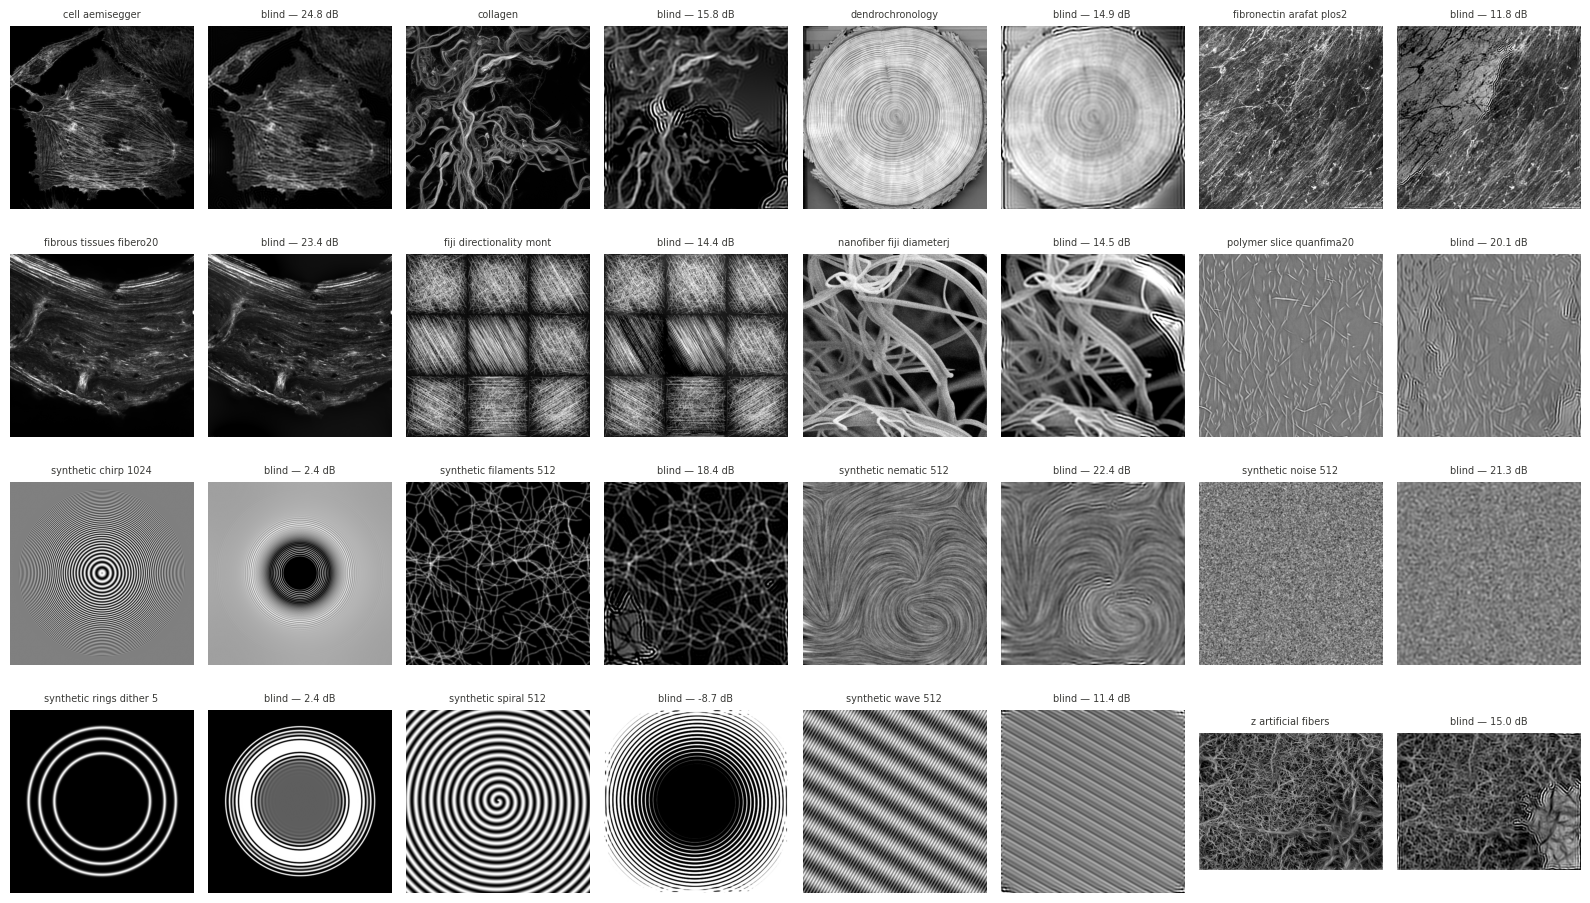

In [4]:
names = list(IMAGES)
fig, axes = plt.subplots(4, 8, figsize=(16, 9.4))
for i, name in enumerate(names):
    row, col = divmod(i, 4)
    ax_gt, ax_rec = axes[row, 2 * col], axes[row, 2 * col + 1]
    ax_gt.imshow(IMAGES[name], cmap='gray', vmin=0, vmax=1)
    ax_gt.set_title(name.replace('_', ' ')[:24], fontsize=7)
    ax_rec.imshow(reconstructions[name], cmap='gray', vmin=0, vmax=1)
    ax_rec.set_title(f'blind — {psnr[SCALES[-1]][name]:.1f} dB', fontsize=7)
for ax in axes.flat:
    ax.axis('off')
fig.tight_layout()
fig.savefig('overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary — PSNR per image and gradient scale

Bars: σ_G = 5; dots: σ_G = 1. Sorted by the σ_G = 5 score.

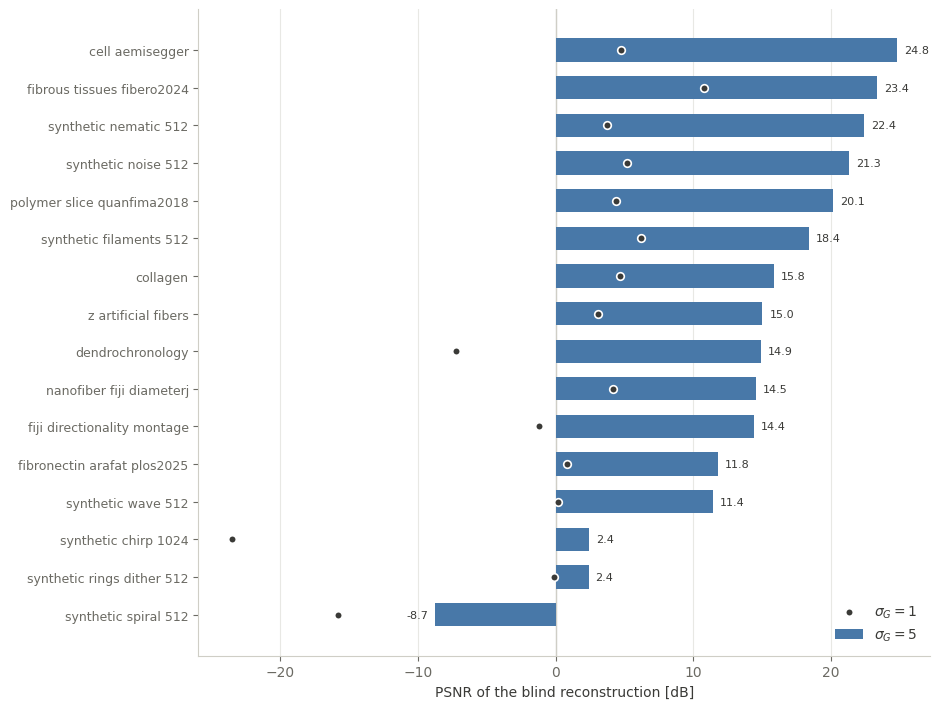

In [5]:
order = sorted(IMAGES, key=lambda n: psnr[SCALES[-1]][n])
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(9.5, 7.2))
ax.barh(y, [psnr[SCALES[-1]][n] for n in order], height=0.62,
        color='#4878a8', zorder=3, label='$\\sigma_G = 5$')
ax.scatter([psnr[SCALES[0]][n] for n in order], y, s=30, color='#3a3a37',
           edgecolors='white', linewidths=1.2, zorder=4,
           label='$\\sigma_G = 1$')
for i, n in enumerate(order):
    v = psnr[SCALES[-1]][n]
    ax.annotate(f'{v:.1f}', (v, i),
                xytext=(5 if v >= 0 else -5, 0), textcoords='offset points',
                va='center', ha='left' if v >= 0 else 'right',
                fontsize=8, color='#3a3a37')
ax.set_yticks(y)
ax.set_yticklabels([n.replace('_', ' ') for n in order], fontsize=9)
ax.axvline(0.0, color='#cfcec6', linewidth=1)
ax.set_xlabel('PSNR of the blind reconstruction [dB]')
ax.grid(True, axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig('psnr.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

- **Blind invertibility is a smoothness question.** At the plugin scale
  σ_G = 1 every test image fails (≤ 11 dB): natural textures and noisy
  synthetics have gradients that vanish densely, and the sign retrieval
  (phase unwrapping) breaks. At σ_G = 5 the gradient field is smooth on most
  images and the blind reconstruction becomes recognizable — best
  `cell_aemisegger` ≈ 25 dB, `fibrous_tissues` ≈ 23 dB, `nematic` ≈ 22 dB.
- **Oscillating images stay lost at any scale** — `spiral` ≈ −9 dB, `chirp`
  and `rings` ≈ 2 dB: the gradient vanishes along whole ridge/valley curves
  and the profile sign flips across them are strictly invisible to (C, E, θ).
  This is an invariance of the features, not a weakness of the method
  (see [../reconstruction](../reconstruction/reconstruction.ipynb)).
- The naive chain is a handful of FFTs plus one phase unwrapping — the whole
  benchmark runs in ≈ half a minute. The iterative refinements of
  `../reconstruction` (joint ADMM, end-to-end variational with the same
  forward operators) start from this output and gain 10–24 dB on smooth
  images.